In [60]:
from rdkit import Chem
from tqdm import tqdm
import pandas as pd

file = '/home/artem/Documents/JUP/Globus.sdf'

molecules = []

with Chem.SDMolSupplier(file) as mol_supplier:
    for i, mol in tqdm(enumerate(mol_supplier)):
        if mol is not None:
            props = mol.GetPropsAsDict()
            props["Title"] = mol.GetProp("KAB")
            props["Mol"] = mol
            molecules.append(props)

df = pd.DataFrame(molecules)
cols = ["Title", "Mol"] + [
    col for col in df.columns if col not in ["Title", "Mol"]
]
df = df[cols]
df

11422it [00:02, 5001.86it/s][13:37:24] Explicit valence for atom # 6 N, 4, is greater than permitted
[13:37:24] ERROR: Could not sanitize molecule ending on line 864260
[13:37:24] ERROR: Explicit valence for atom # 6 N, 4, is greater than permitted
[13:37:24] Explicit valence for atom # 6 N, 4, is greater than permitted
[13:37:24] ERROR: Could not sanitize molecule ending on line 864340
[13:37:24] ERROR: Explicit valence for atom # 6 N, 4, is greater than permitted
[13:37:24] Explicit valence for atom # 6 N, 4, is greater than permitted
[13:37:24] ERROR: Could not sanitize molecule ending on line 864638
[13:37:24] ERROR: Explicit valence for atom # 6 N, 4, is greater than permitted
[13:37:24] Explicit valence for atom # 6 N, 4, is greater than permitted
[13:37:24] ERROR: Could not sanitize molecule ending on line 865640
[13:37:24] ERROR: Explicit valence for atom # 6 N, 4, is greater than permitted
[13:37:24] The 2 defining bonds for an atropisomer are co-planar - atoms are: 17 16
[13:

,Title,Mol,KAB,YAB,MASS,SUPERMASS
0,601,<rdkit.Chem.rdchem.Mol object at 0x791543c90350>,601,93911.0,760,0.0
1,608,<rdkit.Chem.rdchem.Mol object at 0x791543c90190>,608,93.0,3500,NaN
2,612,<rdkit.Chem.rdchem.Mol object at 0x791543c90200>,612,104.0,270,8.0
3,613,<rdkit.Chem.rdchem.Mol object at 0x791543c90270>,613,93915.0,10034,30.0
4,615,<rdkit.Chem.rdchem.Mol object at 0x791543c902e0>,615,93916.0,220,NaN
...,...,...,...,...,...,...
15137,315331,<rdkit.Chem.rdchem.Mol object at 0x791549bb9770>,315331,315331.0,150,NaN
15138,315370,<rdkit.Chem.rdchem.Mol object at 0x791549bb97e0>,315370,315370.0,90,NaN
15139,315537,<rdkit.Chem.rdchem.Mol object at 0x791549bb9850>,315537,315537.0,210,NaN
15140,315625,<rdkit.Chem.rdchem.Mol object at 0x791549bb98c0>,315625,315625.0,160,NaN


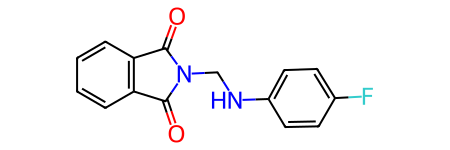

In [2]:
list_of_molecules = df["Mol"].tolist()
list_of_molecules[2]

In [3]:
acyclovir = Chem.MolFromSmiles('NC1=NC(=O)C2=C(N1)N(COCCO)C=N2')
gancyclovir = Chem.MolFromSmiles('NC1=NC2=C(N=CN2COC(CO)CO)C(=O)N1')
foscarnet = Chem.MolFromSmiles('OC(=O)P(O)(O)=O')
cidofovir = Chem.MolFromSmiles('NC1=NC(=O)N(C[C@@H](CO)OCP(O)(O)=O)C=C1')
litermovir = Chem.MolFromSmiles('COC1=CC=CC(=C1)N1CCN(CC1)C1=NC2=C(C=CC=C2F)[C@H](CC(O)=O)N1C1=CC(=CC=C1OC)C(F)(F)F')
pritelivir = Chem.MolFromSmiles ('CN(C(=O)CC1=CC=C(C=C1)C1=CC=CC=N1)C1=NC(C)=C(S1)S(N)(=O)=O')
penciclovir = Chem.MolFromSmiles('NC1=NC(=O)C2=C(N1)N(CCC(CO)CO)C=N2')
alpizarin = Chem.MolFromSmiles('C1=C2C(=CC(=C1O)O)OC3=C(C2=O)C(=C(C(=C3)O)[C@H]4[C@@H]([C@H]([C@@H]([C@H](O4)CO)O)O)O)O')

In [4]:
test_molecules = [acyclovir, gancyclovir, foscarnet, cidofovir, litermovir, pritelivir, penciclovir, alpizarin]
test_molecules_names = ['acyclovir', 'gancyclovir', 'foscarnet', 'cidofovir', 'litermovir', 'pritelivir', 'penciclovir', 'alpizarin']

In [5]:
import numpy as np
from tqdm import tqdm
from rdkit.Chem import rdFingerprintGenerator

from rdkit.Chem.rdFingerprintGenerator import (
    GetMorganGenerator,
    GetRDKitFPGenerator,
    GetAtomPairGenerator,
    GetTopologicalTorsionGenerator,
    GetMorganGenerator
)

from rdkit import DataStructs
from typing import List, Tuple, Any

In [119]:
available_generators = [
    rdFingerprintGenerator.__dict__[k] 
    for k, v in rdFingerprintGenerator.__dict__.items() 
    if k.endswith('Generator')  and 'Invariants' not in k
]
available_generators

[<function rdkit.Chem.rdFingerprintGenerator.GetAtomPairGenerator>,
 <function rdkit.Chem.rdFingerprintGenerator.GetMorganGenerator>,
 <function rdkit.Chem.rdFingerprintGenerator.GetRDKitFPGenerator>,
 <function rdkit.Chem.rdFingerprintGenerator.GetTopologicalTorsionGenerator>]

In [120]:
list_of_generators = [
    (GetMorganGenerator(radius=2, fpSize=1024), 'morgan(radius=2, fpSize=1024)'),
    (GetRDKitFPGenerator(fpSize=2048), 'rdkitfp(fpSize=2048)'),
    (GetAtomPairGenerator(fpSize=2048), 'atompair(fpSize=2048)'),
    (GetTopologicalTorsionGenerator(fpSize=2048), 'topotorsion(fpSize=2048)'),
    (GetMorganGenerator(radius=2, fpSize=1024, atomInvariantsGenerator=rdFingerprintGenerator.GetMorganFeatureAtomInvGen()), 
     'morgan(radius=2, fpSize=1024, invariant=AtomInvGen)'
    )
]

In [121]:
list_of_similarities = [
    DataStructs.__dict__[k] 
    for k, v in DataStructs.__dict__.items() 
    if k.startswith('Bulk') 
    and 'Fingerprint' not in k
    and 'Tver' not in k
]
list_of_similarities

[<function rdkit.DataStructs.cDataStructs.BulkTanimotoSimilarity>,
 <function rdkit.DataStructs.cDataStructs.BulkCosineSimilarity>,
 <function rdkit.DataStructs.cDataStructs.BulkKulczynskiSimilarity>,
 <function rdkit.DataStructs.cDataStructs.BulkDiceSimilarity>,
 <function rdkit.DataStructs.cDataStructs.BulkSokalSimilarity>,
 <function rdkit.DataStructs.cDataStructs.BulkMcConnaugheySimilarity>,
 <function rdkit.DataStructs.cDataStructs.BulkAsymmetricSimilarity>,
 <function rdkit.DataStructs.cDataStructs.BulkBraunBlanquetSimilarity>,
 <function rdkit.DataStructs.cDataStructs.BulkRusselSimilarity>,
 <function rdkit.DataStructs.cDataStructs.BulkRogotGoldbergSimilarity>,
 <function rdkit.DataStructs.cDataStructs.BulkOnBitSimilarity>,
 <function rdkit.DataStructs.cDataStructs.BulkAllBitSimilarity>]

In [122]:
similarity_names = [
    'tanimoto','cosine', 'kulczynski', 
    'dice', 'sokal','mcconnaughey',
    'assymetric', 'braunblanque', 'russel',
    'rogot','onbit','allbit'
]

In [123]:
assert len(list_of_similarities) == len(similarity_names)

In [124]:
full_list_of_similarites = [(x, y) for x, y in zip(list_of_similarities, similarity_names)]
full_list_of_similarites

[(<function rdkit.DataStructs.cDataStructs.BulkTanimotoSimilarity>,
  'tanimoto'),
 (<function rdkit.DataStructs.cDataStructs.BulkCosineSimilarity>, 'cosine'),
 (<function rdkit.DataStructs.cDataStructs.BulkKulczynskiSimilarity>,
  'kulczynski'),
 (<function rdkit.DataStructs.cDataStructs.BulkDiceSimilarity>, 'dice'),
 (<function rdkit.DataStructs.cDataStructs.BulkSokalSimilarity>, 'sokal'),
 (<function rdkit.DataStructs.cDataStructs.BulkMcConnaugheySimilarity>,
  'mcconnaughey'),
 (<function rdkit.DataStructs.cDataStructs.BulkAsymmetricSimilarity>,
  'assymetric'),
 (<function rdkit.DataStructs.cDataStructs.BulkBraunBlanquetSimilarity>,
  'braunblanque'),
 (<function rdkit.DataStructs.cDataStructs.BulkRusselSimilarity>, 'russel'),
 (<function rdkit.DataStructs.cDataStructs.BulkRogotGoldbergSimilarity>,
  'rogot'),
 (<function rdkit.DataStructs.cDataStructs.BulkOnBitSimilarity>, 'onbit'),
 (<function rdkit.DataStructs.cDataStructs.BulkAllBitSimilarity>, 'allbit')]

In [125]:
def get_tables_result(
    molecules: List[Chem.rdchem.Mol],
    test_set_molecules: List[Chem.rdchem.Mol],
    list_of_inital_generatos: List[Tuple[rdFingerprintGenerator.FingeprintGenerator64, str]],
    list_of_similarity_metrics: List[Tuple[Any, str]],
    data_names: List[str],
    test_molecules_data_names: List[str]
):
    tables = {}
    for (gen, gen_name) in list_of_inital_generatos:
        list_of_fingerprints = []
        for mol in molecules:
                    list_of_fingerprints.append(gen.GetFingerprint(mol))
        for (metric, metric_name) in list_of_similarity_metrics:
            current_generator = []
            for current_test_mol in tqdm(test_set_molecules):
                x = gen.GetFingerprint(current_test_mol)
                z = metric(x,list_of_fingerprints)
                current_generator.append(z)
            key = f'gen: {gen_name}, sim: {metric_name}'
            current_dataframe = pd.DataFrame(current_generator, columns=data_names)
            current_dataframe.index = test_molecules_data_names
            current_dataframe = current_dataframe.T
            current_dataframe.name = key
            tables[key] = {'gen': gen, 'metric': metric, 'data': current_dataframe}
    return tables

In [126]:
result = get_tables_result(list_of_molecules, test_molecules, list_of_generators, full_list_of_similarites, df['Title'], test_molecules_names)

100%|████████████████████████████████████████████| 8/8 [00:00<00:00, 434.10it/s]


In [128]:
keys = list(result.keys())

In [129]:
len(keys)

60

In [147]:
sample = pd.DataFrame(result[keys[-41]]['data'])
print(keys[-41])
sample.to_excel("output.xlsx")  
sample

gen: rdkitfp(fpSize=2048), sim: braunblanque


,acyclovir,gancyclovir,foscarnet,cidofovir,litermovir,pritelivir,penciclovir,alpizarin
Title,,,,,,,,
601,0.388283,0.394631,0.031335,0.305177,0.399601,0.396480,0.402685,0.380629
608,0.304167,0.304698,0.026549,0.316814,0.301197,0.300207,0.315436,0.295667
612,0.291667,0.292617,0.027322,0.316940,0.297872,0.296066,0.295302,0.279524
613,0.287500,0.287248,0.026465,0.316176,0.281250,0.287785,0.289933,0.271028
615,0.369737,0.381579,0.026316,0.305263,0.400266,0.402692,0.390789,0.369584
...,...,...,...,...,...,...,...,...
315331,0.369412,0.384706,0.031765,0.281176,0.409574,0.480331,0.384706,0.407816
315370,0.365098,0.380023,0.030999,0.280138,0.420213,0.493789,0.380023,0.422260
315537,0.358629,0.373317,0.030600,0.287638,0.388963,0.456522,0.376989,0.398471


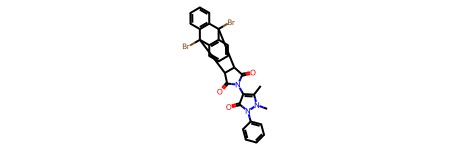

In [131]:
df['Mol'].iloc[6238]